In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import cv2

In [4]:
img = cv2.imread('./image_ds/maria_sharapova/sharapova-hits-the-practice-courts-and-met-ball-kids.jpg')
img.shape

(555, 700, 3)

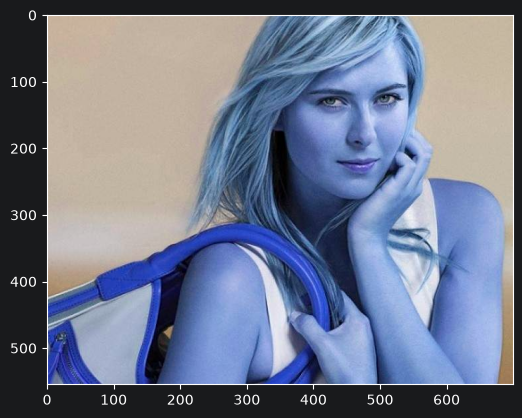

In [5]:
plt.imshow(img)

doing this removes the RGB (3rd dimension)

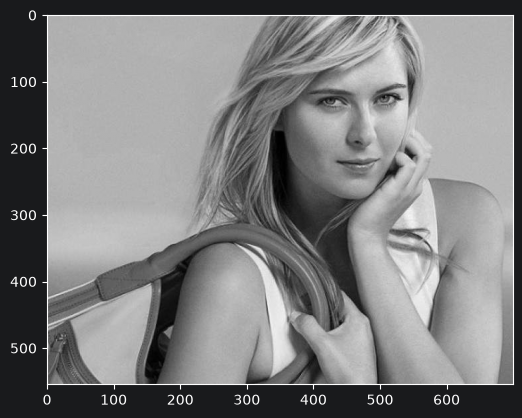

In [6]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap='gray')

haar features in open cv for facial recognition

In [7]:
face_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_eye.xml')
faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces

array([[352,  38, 233, 233]], dtype=int32)

In [8]:
[x, y, w, h] = faces[0]
x,y,w,h

(np.int32(352), np.int32(38), np.int32(233), np.int32(233))

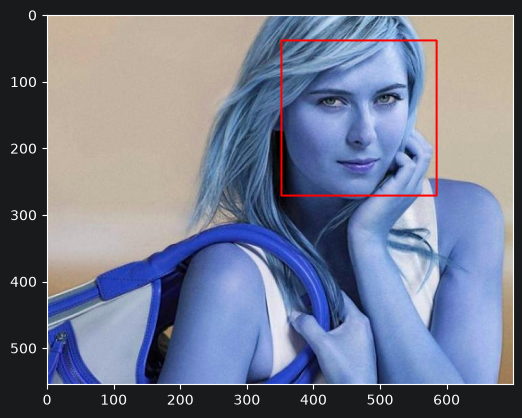

In [9]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

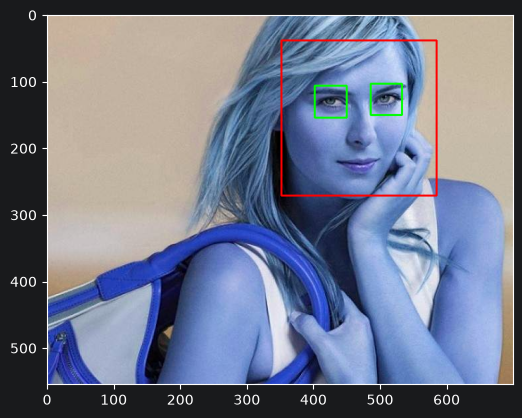

In [10]:
cv2. destroyAllWindows()
for (x,y, w,h) in faces:
    face_img = cv2.rectangle(img, (x,y), (x+w,y+h), (255, 0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0,255,0), 2)
plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

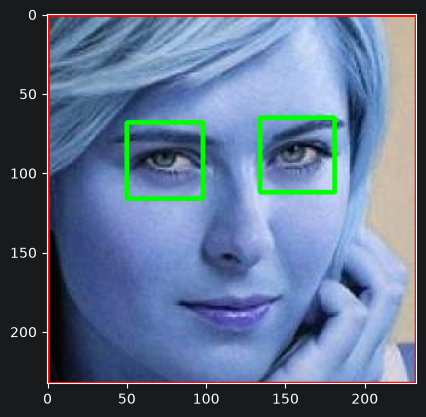

In [11]:
plt.imshow(roi_color, cmap='gray')

In [12]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y, w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color

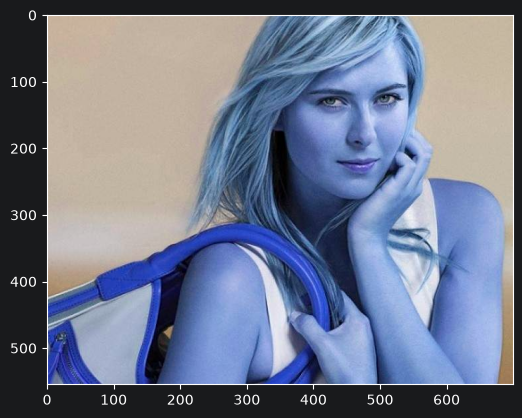

In [13]:
og_image = cv2.imread('./test_images/sharapova1.jpg')
plt.imshow(og_image)

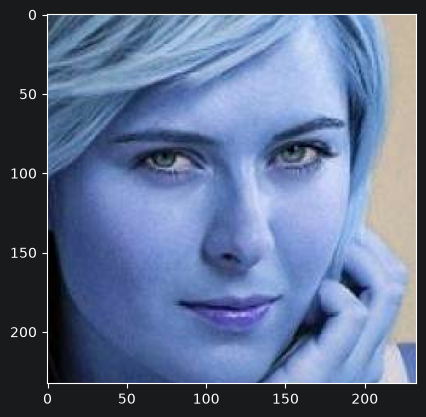

In [14]:
cropped_image  = get_cropped_image_if_2_eyes('./test_images/sharapova1.jpg')
plt.imshow(cropped_image)

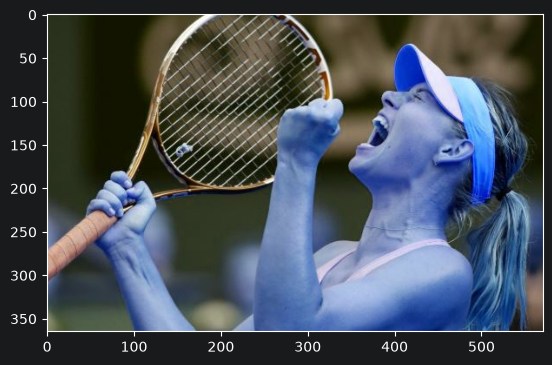

In [15]:
og_image = cv2.imread('./test_images/sharapova2.JPG')
plt.imshow(og_image)

In [16]:
path_to_data = "./dataset/"
path_to_cr_data = "./dataset/cropped/"

In [17]:
import os

img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        if entry.name == "cropped" or entry.name.startswith('.'):
            continue
        img_dirs.append(entry.path)

In [18]:
img_dirs

['./dataset/maria_sharapova',
 './dataset/virat_kohli',
 './dataset/messi',
 './dataset/serena_williams',
 './dataset/roger_federer']

In [19]:
import shutil
if os. path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [20]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    print(celebrity_name)

    celebrity_file_names_dict[celebrity_name] = []

    # Define the exact folder path cleanly
    cropped_folder = path_to_cr_data + celebrity_name

    # FIX 1: Check and create the folder ONCE per celebrity, not inside the image loop
    if not os.path.exists(cropped_folder):
        os.makedirs(cropped_folder)
        cropped_image_dirs.append(cropped_folder)
        print("Generating cropped images in folder: ", cropped_folder)

    for entry in os.scandir(img_dir):
        # FIX 2: Skip hidden operating system files like .DS_Store
        if entry.name.startswith('.') or not entry.is_file():
            continue

        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            # FIX 3: Properly format the unique file name and path using forward slashes safely
            cropped_file_name = celebrity_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name

            # Save the cropped array directly to your drive
            cv2.imwrite(cropped_file_path, roi_color)

            # Append the saved file path to your dictionary tracking list
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1

maria_sharapova
Generating cropped images in folder:  ./dataset/cropped/maria_sharapova
virat_kohli
Generating cropped images in folder:  ./dataset/cropped/virat_kohli
messi
Generating cropped images in folder:  ./dataset/cropped/messi
serena_williams
Generating cropped images in folder:  ./dataset/cropped/serena_williams
roger_federer
Generating cropped images in folder:  ./dataset/cropped/roger_federer


Feature engineering

In [21]:
import numpy as np
import pywt
import cv2

def w2d(img, mode='haar', level=1):
    imArray = img

   #Datatype conversions #convert to grayscale
    imArray = cv2.cvtColor(imArray, cv2.COLOR_BGR2GRAY)

    # Convert to float
    imArray = np.float32(imArray)
    imArray /= 255

    # Compute coefficients
    coeffs = pywt.wavedec2(imArray, mode, level=level)

    # Process Coefficients
    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0

    # Reconstruction
    imArray_H = pywt.waverec2(coeffs_H, mode)
    imArray_H *= 255
    imArray_H = np.uint8(imArray_H)

    return imArray_H

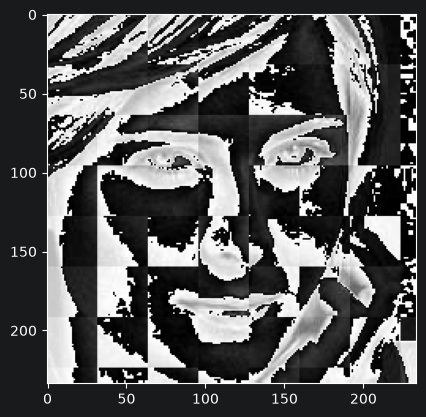

In [22]:
im_har = w2d(cropped_image,'db1',5)
plt.imshow(im_har,cmap='gray')

In [23]:
celebrity_file_names_dict #dict containing name of celeb as key and value is the path to img

{'maria_sharapova': ['./dataset/cropped/maria_sharapova/maria_sharapova1.png',
  './dataset/cropped/maria_sharapova/maria_sharapova2.png',
  './dataset/cropped/maria_sharapova/maria_sharapova3.png',
  './dataset/cropped/maria_sharapova/maria_sharapova4.png',
  './dataset/cropped/maria_sharapova/maria_sharapova5.png',
  './dataset/cropped/maria_sharapova/maria_sharapova6.png',
  './dataset/cropped/maria_sharapova/maria_sharapova7.png',
  './dataset/cropped/maria_sharapova/maria_sharapova8.png',
  './dataset/cropped/maria_sharapova/maria_sharapova9.png',
  './dataset/cropped/maria_sharapova/maria_sharapova10.png',
  './dataset/cropped/maria_sharapova/maria_sharapova11.png',
  './dataset/cropped/maria_sharapova/maria_sharapova12.png',
  './dataset/cropped/maria_sharapova/maria_sharapova13.png',
  './dataset/cropped/maria_sharapova/maria_sharapova14.png',
  './dataset/cropped/maria_sharapova/maria_sharapova15.png',
  './dataset/cropped/maria_sharapova/maria_sharapova16.png',
  './dataset/c

In [24]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'maria_sharapova': 0,
 'virat_kohli': 1,
 'messi': 2,
 'serena_williams': 3,
 'roger_federer': 4}

In [76]:
X = []
y = []

for celebrity_name,training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img  is None:
            continue
        scaled_raw_img = cv2.resize(img,(32,32))
        img_har = w2d(img,'db1',5)
        scaled_img_har = cv2.resize(img_har,(32,32))
        combined_img = np.vstack((scaled_raw_img.reshape(32*32*3,1),scaled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(celebrity_name)

[ WARN:0@1259.802] global loadsave.cpp:278 findDecoder imread_('./dataset/cropped/maria_sharapova/maria_sharapova8.png'): can't open/read file: check file path/integrity
[ WARN:0@1259.865] global loadsave.cpp:278 findDecoder imread_('./dataset/cropped/virat_kohli/virat_kohli2.png'): can't open/read file: check file path/integrity
[ WARN:0@1259.866] global loadsave.cpp:278 findDecoder imread_('./dataset/cropped/virat_kohli/virat_kohli5.png'): can't open/read file: check file path/integrity
[ WARN:0@1259.868] global loadsave.cpp:278 findDecoder imread_('./dataset/cropped/virat_kohli/virat_kohli8.png'): can't open/read file: check file path/integrity
[ WARN:0@1259.869] global loadsave.cpp:278 findDecoder imread_('./dataset/cropped/virat_kohli/virat_kohli10.png'): can't open/read file: check file path/integrity
[ WARN:0@1259.894] global loadsave.cpp:278 findDecoder imread_('./dataset/cropped/virat_kohli/virat_kohli29.png'): can't open/read file: check file path/integrity
[ WARN:0@1259.895]

In [77]:
len(X)

168

reshaping

In [78]:
X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(168, 4096)

Model Building

In [79]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [99]:
X_train,X_test,y_train,y_test = train_test_split(X,y)
pipe = Pipeline([('scaler', StandardScaler()),('svc',SVC(kernel='rbf',C=10))])
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U15](5,)","['maria_sharapova','messi','roger_federer','serena_williams','virat_kohli']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4096
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [100]:
pipe.score(X_test,y_test)

0.8095238095238095

In [101]:
print(classification_report(y_test,pipe.predict(X_test)))

                 precision    recall  f1-score   support

maria_sharapova       0.83      0.91      0.87        11
          messi       0.75      0.86      0.80         7
  roger_federer       0.60      0.60      0.60         5
serena_williams       1.00      0.67      0.80         9
    virat_kohli       0.82      0.90      0.86        10

       accuracy                           0.81        42
      macro avg       0.80      0.79      0.79        42
   weighted avg       0.82      0.81      0.81        42



use gridsearch Cv used to hyper tune parameter

In [102]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [103]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto',probability=True),
        'params' : {
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        # FIX: Changed solver from 'liblinear' to 'lbfgs'
        'model': LogisticRegression(solver='lbfgs', max_iter=10000),
        'params': {
            'logisticregression__C': [1, 5, 10]
        }
    }
}

In [104]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [105]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf =  GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_

df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,svm,0.840615,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.738769,{'randomforestclassifier__n_estimators': 5}
2,logistic_regression,0.841231,{'logisticregression__C': 1}


In [108]:
best_estimators['svm'].score(X_test,y_test)

0.8571428571428571

In [125]:
best_estimators['random_forest'].score(X_test,y_test)

0.5714285714285714

In [126]:
best_clf = best_estimators['svm'].score(X_test,y_test)

<Axes: >

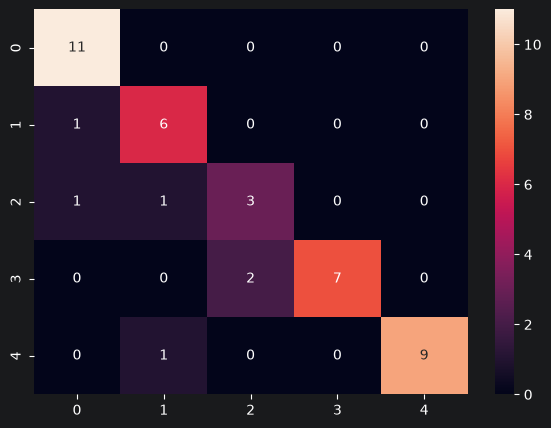

In [127]:
import seaborn as sn
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_estimators['svm'].predict(X_test))
plt.figure(figsize=(7,5))
sn.heatmap(cm,annot=True)

In [128]:
import joblib
joblib.dump(best_clf,'model.pkl')

['model.pkl']

Save Class Dictionary

In [129]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))